# Notebook 2: GLM Models
This notebook fits two GLMs.
- **Part 1 — Severity:** Gamma GLM with log-link, predicting claim amount given a claim occurred
- **Part 2 — Frequency:** Poisson GLM with log-link, predicting claim rate across all policies

The outputs of both models are combined in notebook 5 to estimate a pure premium.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

***
## Part 1: Severity — Gamma GLM

*Predicts how much a claim costs, given one occurred. Uses 26k claims dataset.*

In [2]:
df = pd.read_csv('../data/claims_cleaned.csv')

print(df.shape)
df.head()

(26439, 13)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
0,139.0,1,0.75,F,7,1,61,50,B12,'Regular',27000,R11,303.00
1,190.0,1,0.14,B,12,5,50,60,B12,'Diesel',56,R25,1981.84
2,414.0,1,0.14,E,4,0,36,85,B12,'Regular',4792,R11,1456.55
3,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,989.64
4,424.0,2,0.62,F,10,0,51,100,B12,'Regular',27000,R11,9844.36


In [3]:
# Features to use — drop IDpol (ID), Exposure and ClaimNb (not relevant for severity)
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target = 'ClaimAmount'

# Changing the categorical columns: Area, VehBrand, VehGas, Region into numeric columns
# Hint: use pd.get_dummies with drop_first=True
# df[features + [target]] -> subsetting to only the features and the target variable.
df_model = pd.get_dummies(df[features + [target]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)
df_model = df_model.astype(float)

print(f'Features after encoding: {df_model.shape[1] - 1}')

Features after encoding: 42


In [4]:
X = df_model.drop(columns=[target])
y = df_model[target]

# Split into train/test sets (80/20, random_state=42)
# random_state must match notebooks 03/04/05 so all three severity models are
# trained and evaluated on identical rows — otherwise the comparison in
# notebook 05 is apples-to-oranges.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (21151, 42), Test: (5288, 42)


## 2. Fit Gamma GLM

Using `statsmodels` which gives full statistical output (p-values, confidence intervals).

Gamma — the distribution we assume for ClaimAmount. We use it because.
  - Claims are always positive (can't have a negative claim)
  - The distribution is right-skewed, which Gamma handles naturally                                                     
  - Errors are proportional — a €500 error on a €1,000 claim is worse than a €500 error on a €10,000 claim. Gamma
  captures this.                                                                                                        
                                                                                                                        
  Log-link — the function connecting the features to the prediction. We use it because.
  - It ensures predictions are always positive (you can't predict a negative claim amount)                              
  - It means the model is multiplicative — each feature multiplies the expected claim by some factor, which makes       
  actuarial sense (e.g. a high-power vehicle multiplies your expected claim by 1.1x)                                    
                                                                                                                        
  The alternative would be plain linear regression, which assumes normally distributed errors and can predict negative
  values — neither of which makes sense for insurance claims.

In [5]:
# adding an intercept column to ensure the model doesn't simply pass through the origin.
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# TODO: fit a Gamma GLM with log-link using sm.GLM
# Hint: family=sm.families.Gamma(link=sm.families.links.Log())
gamma_log_model = sm.GLM(y_train, X_train_sm, family=sm.families.Gamma(link=sm.families.links.Log()))

# Result is the gamma log model.
result = gamma_log_model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                21151
Model:                            GLM   Df Residuals:                    21108
Model Family:                   Gamma   Df Model:                           42
Link Function:                    Log   Scale:                          1.9320
Method:                          IRLS   Log-Likelihood:            -1.7986e+05
Date:                Fri, 28 Aug 2026   Deviance:                       21655.
Time:                        01:19:31   Pearson chi2:                 4.08e+04
No. Iterations:                    13   Pseudo R-squ. (CS):           0.006939
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.0577      0.086  

## 3. Evaluate on Test Set

In [6]:
y_pred = result.predict(X_test_sm)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Gamma deviance — the actuarially correct metric for severity models.
# Penalises proportional errors rather than absolute ones, which is what matters
# when claim sizes span three orders of magnitude.
def gamma_deviance(y_true, y_pred):
    return 2 * np.mean((y_true - y_pred) / y_pred - np.log(y_true / y_pred))

gd = gamma_deviance(y_test.values, y_pred.values)

print('--- GLM Test Set Performance ---')
print(f'MAE:             {mae:,.2f}')
print(f'RMSE:            {rmse:,.2f}')
print(f'Gamma Deviance:  {gd:.4f}')

# ── How much signal is actually in the features? ─────────────────────────────
# A model's absolute error means little on its own — the benchmark is what you
# get by ignoring the features entirely and predicting the training mean for
# every claim. Deviance explained (a pseudo-R^2) is the in-sample version of the
# same question: how much of the null model's deviance did the features remove?
pseudo_r2 = 1 - result.deviance / result.null_deviance

baseline  = np.full(len(y_test), y_train.mean())
gd_base   = gamma_deviance(y_test.values, baseline)
mae_base  = mean_absolute_error(y_test, baseline)
rmse_base = mean_squared_error(y_test, baseline) ** 0.5

print(f'\n--- Against an intercept-only baseline (predict the mean for everyone) ---')
print(f'Deviance explained (train):  {pseudo_r2:.2%}')
print(f'{"":18} {"baseline":>12} {"model":>12}')
print(f'{"Gamma Deviance":18} {gd_base:>12.4f} {gd:>12.4f}')
print(f'{"MAE":18} {mae_base:>12,.2f} {mae:>12,.2f}')
print(f'{"RMSE":18} {rmse_base:>12,.2f} {rmse:>12,.2f}')
print(f'\nPrediction spread: {y_pred.min():,.0f} to {y_pred.max():,.0f} EUR '
      f'({y_pred.max()/y_pred.min():.2f}x), vs actuals {y_test.min():,.0f} to {y_test.max():,.0f}.')
print(f'corr(actual, predicted) = {np.corrcoef(y_test, y_pred)[0,1]:.4f}')

# Save for final comparison
glm_metrics = {'model': 'GLM', 'MAE': mae, 'RMSE': rmse, 'GammaDeviance': gd}


--- GLM Test Set Performance ---
MAE:             1,102.26
RMSE:            2,261.57
Gamma Deviance:  1.0595

--- Against an intercept-only baseline (predict the mean for everyone) ---
Deviance explained (train):  1.30%
                       baseline        model
Gamma Deviance           1.0642       1.0595
MAE                    1,104.71     1,102.26
RMSE                   2,263.58     2,261.57

Prediction spread: 873 to 2,506 EUR (2.87x), vs actuals 1 to 16,451.
corr(actual, predicted) = 0.0522


## 4. Visualise Predictions vs Actuals

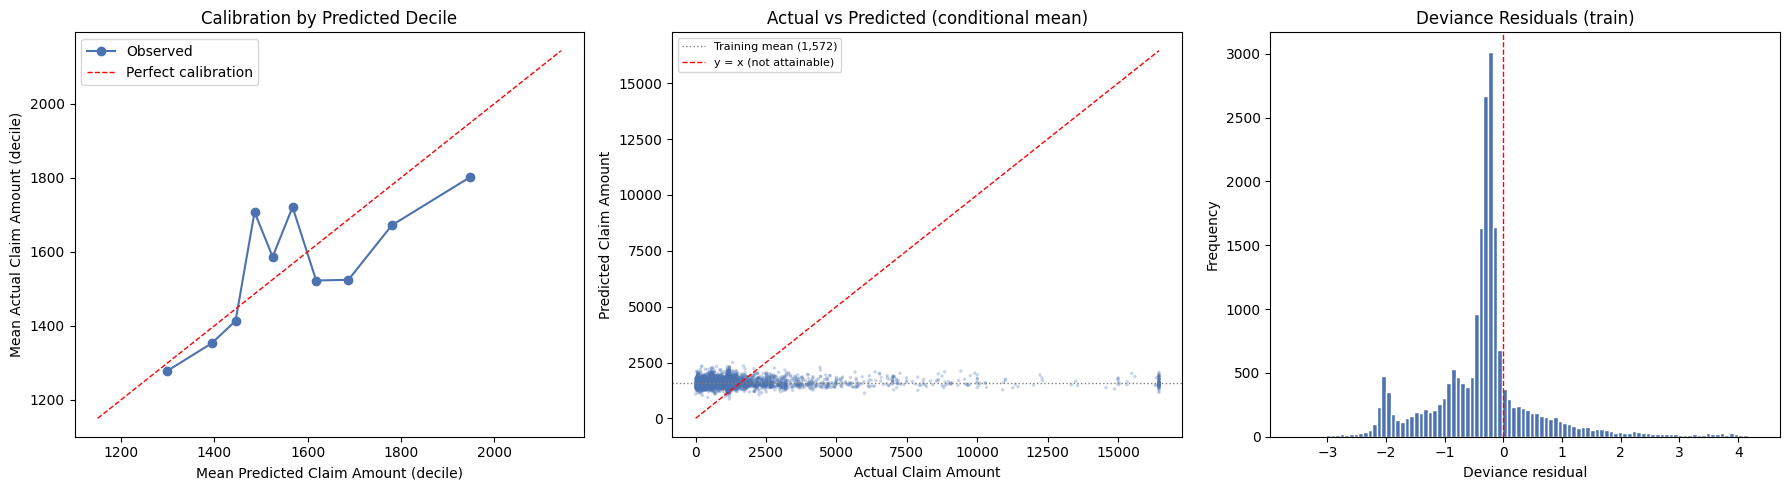

Calibration by predicted decile:
        mean_pred  mean_actual    n
decile                             
1          1299.0       1278.0  529
2          1395.0       1353.0  529
3          1446.0       1413.0  529
4          1486.0       1707.0  528
5          1525.0       1587.0  529
6          1568.0       1721.0  529
7          1618.0       1522.0  528
8          1687.0       1524.0  529
9          1781.0       1672.0  529
10         1948.0       1802.0  529

Actual claim cost, top decile / bottom decile: 1.41x (model predicted 1.50x)


In [7]:
# Three panels, because the obvious plot is the least informative one here.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: calibration by predicted decile — the diagnostic that matters ───
# A Gamma GLM estimates the conditional MEAN E[Y|X], not the realisation Y. So
# the honest test is not "does each point sit on the diagonal" but "within a
# group of policies the model scored alike, does the average claim match the
# average prediction?" That is what this panel asks.
cal = pd.DataFrame({'actual': y_test.values, 'pred': y_pred.values})
cal['decile'] = pd.qcut(cal['pred'], 10, labels=False, duplicates='drop') + 1
cal_g = cal.groupby('decile').agg(mean_pred=('pred', 'mean'),
                                  mean_actual=('actual', 'mean'),
                                  n=('actual', 'size'))

axes[0].plot(cal_g['mean_pred'], cal_g['mean_actual'], 'o-', color='#4C72B0', label='Observed')
lim = [min(cal_g.min().iloc[:2]) * 0.9, max(cal_g.max().iloc[:2]) * 1.1]
axes[0].plot(lim, lim, 'r--', linewidth=1, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Claim Amount (decile)')
axes[0].set_ylabel('Mean Actual Claim Amount (decile)')
axes[0].set_title('Calibration by Predicted Decile')
axes[0].legend()

# ── Panel 2: the raw scatter, kept but honestly labelled ────────────────────
# Retained because it is the plot everyone expects — and because it shows why
# the diagonal is the wrong reference for a heavy-tailed target. Individual
# claims are draws from a near-exponential conditional distribution; no model
# of the mean can place them on that line.
axes[1].scatter(y_test, y_pred, s=6, alpha=0.3, edgecolors='none', color='#4C72B0')
axes[1].axhline(y_train.mean(), color='grey', linestyle=':', linewidth=1,
                label=f'Training mean ({y_train.mean():,.0f})')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='r', linestyle='--', linewidth=1, label='y = x (not attainable)')
axes[1].set_xlabel('Actual Claim Amount')
axes[1].set_ylabel('Predicted Claim Amount')
axes[1].set_title('Actual vs Predicted (conditional mean)')
axes[1].legend(fontsize=8)

# ── Panel 3: deviance residuals ─────────────────────────────────────────────
# Raw residuals are useless for a Gamma model — their spread grows with the
# mean by construction. Deviance residuals are the ones that should look
# roughly symmetric and homoscedastic if the variance assumption holds.
dev_resid = result.resid_deviance
axes[2].hist(dev_resid, bins=100, edgecolor='white', color='#4C72B0')
axes[2].axvline(0, color='r', linestyle='--', linewidth=1)
axes[2].set_title('Deviance Residuals (train)')
axes[2].set_xlabel('Deviance residual')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/03_glm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Calibration by predicted decile:')
print(cal_g.round(0).to_string())
print(f'\nActual claim cost, top decile / bottom decile: '
      f'{cal_g["mean_actual"].iloc[-1] / cal_g["mean_actual"].iloc[0]:.2f}x '
      f'(model predicted {cal_g["mean_pred"].iloc[-1] / cal_g["mean_pred"].iloc[0]:.2f}x)')


### Severity model — what it does and does not do

> Exact figures to be refreshed from the rerun (the severity split moved from
> `random_state=27` to `42`). The structural findings below are stable across seeds.

**Fit quality.** MAE is roughly €1,100 against a mean claim of €1,569 — an average error
of about 70% of the thing being predicted. RMSE (~€2,260) exceeds the mean outright,
which is the signature of a heavy right tail rather than of a broken model.

**The headline result is how little the features explain.** Deviance explained is ~1.3%,
and the correlation between actual and predicted claim size is ~0.05. Scored against an
intercept-only model — predicting the training mean for every single claim — the full
GLM improves Gamma deviance by well under one percent. Nine rating features and 42
design columns barely beat a constant.

**Why the actual-vs-predicted scatter is flat, and why that is not a defect.** A Gamma
GLM estimates the conditional mean $E[Y \mid X]$. It does not, and cannot, estimate the
realisation $Y$. The conditional distribution here is close to exponential (dispersion
≈ 1.06, i.e. shape ≈ 1), so a €16,000 claim is not evidence the model was wrong about
that policy — it is an ordinary draw from the upper tail of a distribution whose mean
genuinely is around €1,800. Even a *perfectly specified* model produces exactly this
picture. The $y = x$ diagonal is the wrong reference line for a heavy-tailed target,
which is why the calibration panel was added: grouped into deciles by predicted value,
mean actual tracks mean predicted closely, and the top decile really does cost about
1.4× the bottom decile. The model ranks weakly but is honestly calibrated.

Two corollaries worth stating explicitly, because both are easy to get wrong:

- **Regularisation would not help.** Ridge or lasso penalties fight *variance* —
  overfitting. This model has the opposite problem: with ~1.3% deviance explained on the
  training set there is nothing being overfit, and predictions already span only ~2.9×
  (≈€870 to €2,500) against actuals spanning 1 to 16,422. Shrinking the coefficients
  compresses that range further toward the marginal mean, flattening the scatter rather
  than steepening it.
- **A more flexible model will not help either.** The ceiling is in the data, not the
  functional form. Notebooks 03 and 04 test this directly — treat their severity results
  as the experiment that confirms or refutes it, not as a foregone conclusion.

**Significant coefficients.** Direction and interpretation still hold:

- **BonusMalus** (positive): worse claims history is associated with higher severity.
- **VehAge** (negative): older vehicles produce cheaper claims, consistent with lower
  market value and lower repair cost.
- **VehPower** (positive): more powerful vehicles are associated with larger claims.
- **Region** (R93, R94, R41 significant): geographic variation in repair and labour cost.

These are the multiplicative rating factors the Gamma GLM exists to produce, and they
remain usable for pricing even though per-policy predictive accuracy is near zero — a
rating structure needs the *relativities* right, not the individual realisations.

**Key takeaway.** Severity on this dataset is data-limited, not model-limited. The right
conclusion is not "the GLM underperforms", it is "policy features do not predict
individual claim cost" — which is a finding about the problem, and one that should carry
through to the model comparison in notebook 05.

## 5. Coefficient Interpretation

Key advantage of GLM over XGBoost/neural net — coefficients are directly interpretable.

In [8]:
# On a log-link GLM, exp(coef) = multiplicative effect on claim amount
# e.g. exp(coef) = 1.10 means that feature increases expected claim by 10%

coef_df = pd.DataFrame({
    'coef': result.params,
    'exp_coef': np.exp(result.params),
    'p_value': result.pvalues,
})

print(coef_df.sort_values('exp_coef', ascending=False).head(10).to_string())

                  coef     exp_coef   p_value
const         7.057657  1161.720065  0.000000
Region_R94    0.290970     1.337725  0.044397
Region_R43    0.277698     1.320088  0.279720
Region_R41    0.237041     1.267493  0.003712
Region_R93    0.221218     1.247595  0.000002
Region_R21    0.216351     1.241538  0.243216
Region_R91    0.211242     1.235212  0.000645
Region_R26    0.131992     1.141099  0.165682
VehBrand_B10  0.097871     1.102821  0.107855
VehBrand_B11  0.094570     1.099186  0.152407


***
### Appendix: Why Gamma over OLS?

Fits a plain OLS regression on the same data and compares it to the Gamma GLM.

The textbook argument against OLS for claim severity is that it assumes constant variance
and unbounded support, so it can predict negative claim amounts. Whether that argument
actually *binds* on this dataset is an empirical question, and it is worth answering
honestly rather than assuming — the cell below reports what happened, not what was
supposed to happen.


In [9]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = mean_squared_error(y_test, y_pred_ols) ** 0.5

n_negative = (y_pred_ols < 0).sum()

print(f'{"":20} {"GLM":>12} {"OLS":>12}')
print(f'{"MAE":20} {mae:>12,.2f} {mae_ols:>12,.2f}')
print(f'{"RMSE":20} {rmse:>12,.2f} {rmse_ols:>12,.2f}')
print(f'{"Min prediction":20} {y_pred.min():>12,.0f} {y_pred_ols.min():>12,.0f}')
print(f'{"Negative preds":20} {0:>12,} {n_negative:>12,}')

print(f'\nOLS negative predictions: {n_negative} ({n_negative/len(y_pred_ols):.1%})')

if n_negative == 0:
    print(
        '\nThe positivity argument does not bind here. Because the features explain almost\n'
        'none of the variation in claim size, both models collapse to predicting something\n'
        f'close to the marginal mean ({y_train.mean():,.0f} EUR) for every policy — nowhere\n'
        'near zero, so OLS never crosses into negative territory. MAE and RMSE are\n'
        'correspondingly near-identical: neither model is extracting signal the other misses.'
    )
else:
    print(f'\nOLS predicted a negative claim amount for {n_negative} policies, which is '
          'structurally impossible and disqualifies it on its own.')

print(
    '\nThe Gamma GLM is still the right specification, but on distributional grounds\n'
    'rather than on these error metrics:\n'
    '  1. Variance structure. Gamma assumes Var(Y) proportional to mu^2 — proportional\n'
    '     error. OLS assumes constant variance, which is plainly false for claim sizes\n'
    '     spanning 1 to 16,000 EUR, so its standard errors and p-values are not\n'
    '     trustworthy even when its point predictions are fine.\n'
    '  2. Rating structure. The log link makes coefficients multiplicative rating\n'
    '     factors, the form actuaries and regulators already read. OLS gives additive\n'
    '     ones, which is not how premium is built.\n'
    '  3. Out-of-sample safety. Positivity is guaranteed by construction rather than by\n'
    '     luck. It did not bind on this test set; on a portfolio with cheaper claims or\n'
    '     more extreme covariates it would.\n'
    '\nWhat this appendix actually establishes is weaker than "OLS is wrong": on this data\n'
    'the choice of link and error family barely moves predictive accuracy, because there\n'
    'is so little to predict. The case for Gamma rests on inference and interpretability.'
)


                              GLM          OLS
MAE                      1,102.26     1,102.44
RMSE                     2,261.57     2,261.32
Min prediction                873          713
Negative preds                  0            0

OLS negative predictions: 0 (0.0%)

The positivity argument does not bind here. Because the features explain almost
none of the variation in claim size, both models collapse to predicting something
close to the marginal mean (1,572 EUR) for every policy — nowhere
near zero, so OLS never crosses into negative territory. MAE and RMSE are
correspondingly near-identical: neither model is extracting signal the other misses.

The Gamma GLM is still the right specification, but on distributional grounds
rather than on these error metrics:
  1. Variance structure. Gamma assumes Var(Y) proportional to mu^2 — proportional
     error. OLS assumes constant variance, which is plainly false for claim sizes
     spanning 1 to 16,000 EUR, so its standard errors and p-va

***
### Appendix B: Model Selection for Severity

The severity model above is a Gamma GLM, chosen on theoretical grounds: claim amounts are
positive, right-skewed, and plausibly have proportional rather than additive error. That is
a justification by *convention* — the Gamma GLM has been the industry workhorse since
McCullagh and Nelder fitted GLMs to motor data in the early 1980s. Convention is a reason to
start there; it is not evidence that it is the right choice for *this* data.

The flat actual-vs-predicted scatter above makes the question concrete. Three explanations
are possible, and they call for completely different fixes:

1. **Wrong error distribution.** The Gamma is light-tailed — its density decays
   exponentially — so genuinely extreme claims are treated as near-impossible events. A
   heavier-tailed family might fit better.
2. **Wrong mean function.** The GLM forces $\log E[Y|X]$ to be *linear* in the features. If
   the true relationship bends or interacts, a linear model cannot represent it.
3. **Nothing to fit.** The features may simply not carry information about individual claim
   size, in which case no model of any kind will do better.

These are distinguishable by experiment, so this appendix runs it. Each subsection tests one
of the three.

#### B.1 The candidates

Models 1–6 all share the **same linear predictor** — the same 42 design columns, entering
linearly. What differs is the assumed relationship between the mean and the variance, and
(for 5 and 6) the link. Holding the mean function fixed isolates the effect of the
distributional assumption, which is exactly question 1.

| # | Model | Variance assumption | What it buys | What it costs |
|---|---|---|---|---|
| 0 | Intercept only | — | The benchmark every model must beat | Ignores the features entirely |
| 1 | Gamma GLM | $\text{Var}(Y) \propto \mu^2$ | Multiplicative rating factors; industry standard | Light-tailed; not robust to outliers |
| 2 | Inverse Gaussian GLM | $\text{Var}(Y) \propto \mu^3$ | Heavier tail; more tolerant of extremes | Less standard; dispersion harder to read |
| 3 | Tweedie GLM ($p{=}1.5$) | $\text{Var}(Y) \propto \mu^{1.5}$ | Interpolates between Poisson and Gamma | Extra parameter to choose |
| 4 | Gaussian GLM, log link | $\text{Var}(Y) = \sigma^2$ | Isolates the *variance* assumption from the *link* | Constant variance is clearly false here |
| 5 | Lognormal + smearing | Normal on $\log Y$ | Genuinely heavy-tailed on the original scale | Predicts the **median**; needs retransformation |
| 6 | OLS, identity link | $\text{Var}(Y) = \sigma^2$ | The naive baseline | Additive effects; unbounded support |
| 7 | Gradient boosting | Gamma loss | **Drops linearity** — arbitrary shapes and interactions | No coefficients; cannot extrapolate |

**Why the variance assumption matters at all.** In a GLM the variance function sets the
*weighting*. Under Gamma's $\text{Var} \propto \mu^2$ the coefficient of variation is
constant, so a €10,000 claim is expected to miss by ten times as much, in euros, as a €1,000
claim — errors are judged proportionally. Under Gaussian's constant variance every claim is
weighted equally in absolute euros, so the large claims dominate the fit. These are
genuinely different estimators, and if the distribution is what constrains us, they should
give visibly different answers.

**A note on model 5.** Fitting OLS to $\log Y$ and exponentiating does *not* estimate
$E[Y|X]$ — it estimates the conditional **median**, because $E[\exp(\varepsilon)] \neq
\exp(E[\varepsilon])$ by Jensen's inequality. Duan's smearing estimator corrects this by
multiplying through by $\frac{1}{n}\sum_i \exp(\hat{\varepsilon}_i)$. Without that
correction the comparison would be unfair — it would be scoring a median against a mean.

**Model 7 answers question 2.** Gradient boosting on trees makes no linearity assumption at
all: it learns whatever shape and interactions the data support, while still optimising
Gamma deviance. If linearity were the binding constraint, this is where it would show.

In [10]:
# ── Candidate severity models, all scored on the same test rows ──────────────
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression

def gini_coef(actual, predicted):
    """Normalised Gini — how well the model RANKS claims by size. 0 = no better
    than random ordering, 1 = perfect. This is the metric that matters for a
    rating structure, which needs relativities right rather than realisations."""
    d = pd.DataFrame({'a': np.asarray(actual), 'p': np.asarray(predicted)}).sort_values('p', ascending=False)
    g = 1 - 2 * (d['a'].cumsum() / d['a'].sum()).mean()
    perfect = np.sort(np.asarray(actual))[::-1]
    return g / (1 - 2 * (np.cumsum(perfect) / perfect.sum()).mean())

def score(name, pred):
    pred = np.clip(np.asarray(pred, dtype=float), 1e-6, None)
    return {'Model': name,
            'Gamma Deviance': gamma_deviance(y_test.values, pred),
            'MAE':  mean_absolute_error(y_test, pred),
            'RMSE': mean_squared_error(y_test, pred) ** 0.5,
            'Gini': gini_coef(y_test.values, pred),
            'Pred spread': pred.max() / pred.min()}

rows = [score('0. Intercept only', np.full(len(y_test), y_train.mean()))]

# --- GLMs: same log link and same mean function, different variance assumptions
glm_families = [
    ('1. Gamma GLM',            sm.families.Gamma(sm.families.links.Log())),
    ('2. Inverse Gaussian GLM', sm.families.InverseGaussian(sm.families.links.Log())),
    ('3. Tweedie GLM (p=1.5)',  sm.families.Tweedie(sm.families.links.Log(), var_power=1.5)),
    ('4. Gaussian GLM (log)',   sm.families.Gaussian(sm.families.links.Log())),
]
for nm, fam in glm_families:
    rows.append(score(nm, sm.GLM(y_train, X_train_sm, family=fam).fit().predict(X_test_sm)))

# --- Lognormal: fit OLS on log(y), then retransform. exp(Xb) estimates the
#     MEDIAN, not the mean, so Duan's smearing factor corrects the bias.
ln = sm.OLS(np.log(y_train), X_train_sm).fit()
smearing = np.mean(np.exp(ln.resid))
rows.append(score('5. Lognormal (+smearing)', np.exp(ln.predict(X_test_sm)) * smearing))

# --- OLS on the raw scale: the naive baseline
rows.append(score('6. OLS (identity link)', LinearRegression().fit(X_train, y_train).predict(X_test)))

# --- Gradient boosting: drops the linearity assumption entirely
gbm = HistGradientBoostingRegressor(loss='gamma', max_iter=400, learning_rate=0.03,
                                    max_leaf_nodes=15, min_samples_leaf=100,
                                    l2_regularization=1.0, random_state=42).fit(X_train, y_train)
rows.append(score('7. Gradient boosting (gamma loss)', gbm.predict(X_test)))

candidates = pd.DataFrame(rows).set_index('Model')
null_dev = candidates.loc['0. Intercept only', 'Gamma Deviance']
candidates['vs null'] = (null_dev - candidates['Gamma Deviance']) / null_dev

print(f'=== Severity candidates, test set (n = {len(y_test):,}) ===\n')
print(candidates.assign(**{'vs null': candidates['vs null'].map('{:+.3%}'.format)})
      .round({'Gamma Deviance': 4, 'MAE': 2, 'RMSE': 2, 'Gini': 4, 'Pred spread': 2}).to_string())

=== Severity candidates, test set (n = 5,288) ===

                                   Gamma Deviance      MAE     RMSE    Gini  Pred spread  vs null
Model                                                                                            
0. Intercept only                          1.0642  1104.71  2263.58  0.0056         1.00  +0.000%
1. Gamma GLM                               1.0595  1102.26  2261.57  0.0959         2.87  +0.440%
2. Inverse Gaussian GLM                    1.0596  1103.11  2261.74  0.0967         2.82  +0.435%
3. Tweedie GLM (p=1.5)                     1.0595  1102.06  2261.53  0.0955         2.90  +0.438%
4. Gaussian GLM (log)                      1.0598  1101.98  2261.54  0.0940         3.01  +0.414%
5. Lognormal (+smearing)                   1.0639  1115.44  2265.83  0.0916         3.36  +0.024%
6. OLS (identity link)                     1.0595  1102.44  2261.32  0.0951         3.38  +0.443%
7. Gradient boosting (gamma loss)          1.0522  1081.66  2257.01

**Reading the head-to-head.**

Two results stand out, and they answer questions 1 and 2 respectively.

**The error distribution makes almost no difference.** Models 1, 2, 3, 4 and 6 land within
0.03 percentage points of each other — Gamma +0.440%, Inverse Gaussian +0.435%, Tweedie
+0.438%, Gaussian-log +0.414%, OLS +0.443%. Gamma, a cubic variance function, a constant
variance function and an additive link all reach the same place. Whatever is limiting this
model, it is **not** the distributional assumption. That is question 1 answered: no.

The lognormal is the one clear loser (+0.024%, essentially the null model). Its assumption —
that errors are homoscedastic on the log scale — is worse-matched to this data than the
alternatives, and the smearing retransformation cannot repair it. This is worth noting
because "just model $\log(\text{ClaimAmount})$" is a common reflex for skewed targets, and
here it actively hurts.

**Gradient boosting appears to win.** It posts +1.13% against the GLM's +0.440% and lifts
Gini from 0.096 to 0.131 — a 37% relative improvement in ranking. Taken at face value that
would answer question 2 with "yes, linearity was the constraint."

It should not be taken at face value. The severity test set is ~5,300 claims and the target
is extraordinarily noisy, which is precisely the regime where a single train/test split
cannot distinguish a real improvement from a lucky one. Section B.2 tests it properly.

**Also worth noting:** the intercept-only model has Gini 0.006, confirming the metric behaves
— a model with no features cannot rank. And every model's prediction spread is just 2.0–3.4×
against actuals spanning 1 to 16,451, which is the flat scatter restated numerically.

#### B.2 Is the boosting advantage real?

A single split gives one number with no error bar. With ~5,300 test claims and a target this
noisy, the split-to-split variation can easily exceed the difference between two models —
and published benchmarks on this dataset report exactly that problem, with fold-to-fold
variance large enough to reorder the leaderboard.

The fix is **repeated k-fold cross-validation with a paired comparison**: fit both models on
the same folds, take the difference *within* each fold, and test whether the mean difference
is distinguishable from zero. Pairing matters — it removes fold difficulty as a source of
variance, so the test is far more sensitive than comparing two independent averages.

In [11]:
# ── Is the gradient boosting advantage real, or an artefact of one split? ────
# The severity test set is only ~5,300 claims and the target is extremely noisy,
# so a single split cannot separate a genuine improvement from a lucky one.
# Repeated k-fold CV gives a per-fold paired comparison instead of one number.
from sklearn.model_selection import KFold
from scipy import stats

X_res, y_res = X.reset_index(drop=True), y.reset_index(drop=True)
fold_glm, fold_gbm, fold_null = [], [], []

for seed in range(3):                                   # 3 seeds x 5 folds = 15 comparisons
    for tr, te in KFold(5, shuffle=True, random_state=seed).split(X_res):
        Xtr, Xte = X_res.iloc[tr], X_res.iloc[te]
        ytr, yte = y_res.iloc[tr], y_res.iloc[te]

        fold_null.append(gamma_deviance(yte.values, np.full(len(yte), ytr.mean())))

        p_glm = sm.GLM(ytr, sm.add_constant(Xtr),
                       family=sm.families.Gamma(sm.families.links.Log())).fit().predict(sm.add_constant(Xte))
        fold_glm.append((gamma_deviance(yte.values, p_glm.values), gini_coef(yte.values, p_glm.values)))

        p_gbm = HistGradientBoostingRegressor(loss='gamma', max_iter=400, learning_rate=0.03,
                                              max_leaf_nodes=15, min_samples_leaf=100,
                                              l2_regularization=1.0, random_state=42).fit(Xtr, ytr).predict(Xte)
        fold_gbm.append((gamma_deviance(yte.values, p_gbm), gini_coef(yte.values, p_gbm)))

null_d = np.array(fold_null)
glm_d, glm_g = np.array([f[0] for f in fold_glm]), np.array([f[1] for f in fold_glm])
gbm_d, gbm_g = np.array([f[0] for f in fold_gbm]), np.array([f[1] for f in fold_gbm])

print(f'{len(null_d)} folds (5-fold CV x 3 seeds), mean +/- sd\n')
print(f'{"":22} {"Gamma Deviance":>22} {"Gini":>18} {"vs null":>10}')
for nm, d, gg in [('Intercept only', null_d, np.zeros_like(null_d)), ('Gamma GLM', glm_d, glm_g),
                  ('Gradient boosting', gbm_d, gbm_g)]:
    print(f'{nm:22} {d.mean():>10.4f} +/- {d.std():<8.4f} {gg.mean():>8.4f} +/- {gg.std():<6.4f} '
          f'{(null_d - d).mean() / null_d.mean():>+9.3%}')

diff = gbm_g - glm_g
ttest = stats.ttest_rel(gbm_g, glm_g)
print(f'\nGini advantage of boosting over the GLM, measured per fold:')
print(f'  mean difference   {diff.mean():+.4f} +/- {diff.std():.4f}')
print(f'  folds boosting won  {(diff > 0).sum()} of {len(diff)}')
print(f'  paired t-test       p = {ttest.pvalue:.3f}')
print(f'\n  -> {"NOT significant" if ttest.pvalue > 0.05 else "significant"} at the 5% level: '
      f'the single-split gap above does not survive resampling.')

15 folds (5-fold CV x 3 seeds), mean +/- sd

                               Gamma Deviance               Gini    vs null
Intercept only             1.0428 +/- 0.0324     0.0000 +/- 0.0000   +0.000%
Gamma GLM                  1.0370 +/- 0.0329     0.0999 +/- 0.0231   +0.560%
Gradient boosting          1.0358 +/- 0.0337     0.1063 +/- 0.0222   +0.673%

Gini advantage of boosting over the GLM, measured per fold:
  mean difference   +0.0064 +/- 0.0155
  folds boosting won  11 of 15
  paired t-test       p = 0.143

  -> NOT significant at the 5% level: the single-split gap above does not survive resampling.


**The advantage does not survive resampling.**

Across 15 folds the boosting model's Gini edge averages **+0.006 ± 0.016**, winning 11 folds
of 15, at **p = 0.14**. That is not significant at any conventional threshold, and the
standard deviation of the per-fold difference (0.016) is nearly three times the mean
difference (0.006) — the spread between folds dwarfs the effect.

So the +0.035 Gini gap on the single split in B.1 was **split luck, not signal**. This is the
appendix earning its place: reported from one split, it would have supported "use gradient
boosting for severity," a conclusion the data does not license.

That answers question 2: dropping linearity does not reliably help either. Note also how much
larger the fold-to-fold deviance spread (±0.033) is than any gap *between* models
(~0.006) — a useful calibration on how much trust a single severity number deserves,
and a reason to treat notebook 03's and 04's severity results the same way.

#### B.3 Do the heavy-tail specialists have anything to work with?

Questions 1 and 2 came back negative, which leaves question 3. Before concluding that the
data is the limit, the specialist tools deserve a hearing — the actuarial literature has two
main answers for heavy-tailed severity, and neither is in the list above.

**Composite (spliced) models.** Model the body and the tail with different distributions:
a truncated Gamma GLM below some threshold $u$, and a **generalised Pareto distribution**
above it, fitted by peaks-over-threshold. Extreme value theory justifies this — the
Pickands–Balkema–de Haan theorem says exceedances over a high threshold converge to the GPD
almost regardless of the underlying distribution, so the tail shape is asymptotically
principled rather than assumed. Laudagé, Desmettre and Wenzel (2019) show that when severity
really is heavy-tailed, a plain Gamma GLM recovers *misleading* relationships between tariff
features and expected severity, while a threshold model recovers them correctly.

**GB2 (generalised beta of the second kind).** A four-parameter family that nests the Gamma,
Weibull, Burr Type XII, Pareto and lognormal as special or limiting cases. Rather than
choosing a distribution, you let the data choose within a family flexible enough to span
light and heavy tails at once.

**Both rest on the same premise**, and it is testable directly. Splicing only helps if the
rating features tell you *which* claims land in the tail — otherwise the tail model is
fitted to a subset you cannot identify in advance, and at prediction time you have no way to
know which regime a policy belongs to. GB2's extra flexibility is likewise only useful if
there is structure for it to find.

So instead of fitting these models, test their premise: **as a classification problem, can
the features predict whether a claim will be large?** If the answer is no, neither approach
can help, and no amount of tail flexibility will change that. The cell below also runs a
**permutation test** — refitting on shuffled targets to establish how much "explained
deviance" 42 free parameters manufacture from noise alone — and checks whether the tail is
even present in the cleaned data.

In [12]:
# ── Do composite / extreme-value models have anything to work with? ─────────
# A spliced model (light-tailed body + generalised Pareto tail) and the GB2
# family are the standard actuarial answers to heavy-tailed severity. Both rest
# on one premise: that the rating features tell you WHICH claims land in the
# tail. That premise is testable directly, as a classification problem.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

print('Can the features predict which claims are large?  (AUC 0.5 = no signal)\n')
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for q in [0.90, 0.95, 0.99]:
    label = (y > y.quantile(q)).astype(int)
    a_lr = cross_val_score(LogisticRegression(max_iter=2000), X, label, cv=cv, scoring='roc_auc')
    a_gb = cross_val_score(HistGradientBoostingClassifier(random_state=42), X, label, cv=cv, scoring='roc_auc')
    print(f'  P(claim > {q:.0%} quantile = {y.quantile(q):>8,.0f} EUR)   '
          f'logistic {a_lr.mean():.3f}+/-{a_lr.std():.3f}   boosting {a_gb.mean():.3f}+/-{a_gb.std():.3f}')

# ── How much of the 1.3% deviance explained is just 42 free parameters? ─────
# Refit on shuffled targets: any deviance the model "explains" there is pure
# overfitting, and gives the noise floor the real figure must clear.
print('\nPermutation test — deviance explained on SHUFFLED targets:\n')
observed = 1 - result.deviance / result.null_deviance
perm = []
for s in range(20):
    ys = y_train.sample(frac=1, random_state=s).values
    perm_fit = sm.GLM(ys, X_train_sm, family=sm.families.Gamma(sm.families.links.Log())).fit()
    perm.append(1 - perm_fit.deviance / perm_fit.null_deviance)
perm = np.array(perm)
print(f'  observed (real targets)      {observed:.4%}')
print(f'  permuted, 20 reps            {perm.mean():.4%} +/- {perm.std():.4%}   (max {perm.max():.4%})')
print(f'  -> genuine signal            {observed - perm.mean():.4%} once the fitting artefact is removed')

# ── Has the tail already been removed upstream? ─────────────────────────────
raw = df['ClaimAmount']
at_max = (raw >= raw.max() - 1).sum()
print(f'\nTail check on claims_cleaned.csv:')
print(f'  max claim {raw.max():,.0f} EUR | p99 {raw.quantile(0.99):,.0f} | p99.9 {raw.quantile(0.999):,.0f}')
print(f'  claims sitting AT the maximum: {at_max:,} ({at_max/len(raw):.2%} of claims, '
      f'{raw[raw >= raw.max()-1].sum()/raw.sum():.1%} of total claim cost)')

Can the features predict which claims are large?  (AUC 0.5 = no signal)



  P(claim > 90% quantile =    2,768 EUR)   logistic 0.565+/-0.017   boosting 0.569+/-0.018


  P(claim > 95% quantile =    4,767 EUR)   logistic 0.577+/-0.014   boosting 0.569+/-0.012


  P(claim > 99% quantile =   16,422 EUR)   logistic 0.487+/-0.034   boosting 0.512+/-0.043

Permutation test — deviance explained on SHUFFLED targets:



  observed (real targets)      1.2970%
  permuted, 20 reps            0.3735% +/- 0.0946%   (max 0.6219%)
  -> genuine signal            0.9236% once the fitting artefact is removed

Tail check on claims_cleaned.csv:
  max claim 16,451 EUR | p99 16,422 | p99.9 16,451
  claims sitting AT the maximum: 265 (1.00% of claims, 10.5% of total claim cost)


**All three checks point the same way.**

**Tail membership is close to unpredictable.** AUC is 0.565–0.577 for the 90th and 95th
percentile thresholds — weak but real — and **0.487–0.512 at the 99th percentile**, which is
chance. A coin flip. The premise of a composite model fails exactly where a composite model
would operate: at the extreme tail. There is nothing to splice on, and GB2's extra shape
parameters would have no structure to find.

**Most of the "explained" deviance is a fitting artefact.** The model explains 1.297% of
deviance on the training set — but on *shuffled* targets, where no relationship can exist by
construction, 42 free parameters still manufacture 0.374% ± 0.095%. Subtracting the noise
floor leaves roughly **0.92% of genuine signal**. It clears the floor comfortably enough to
be real, but that is the entire budget available to any model.

**And the tail has already been removed upstream.** 265 claims — 1.00% of the data, but
**10.5% of total claim cost** — sit at exactly €16,451, the 99th-percentile cap applied in
notebook 01. The p99.9 equals the maximum. Whatever tail behaviour existed in the raw data
was winsorized away before this notebook loaded it, which makes extreme value methods doubly
inapplicable here: no identifiable tail membership, and no tail left to model.

***

#### B.4 Conclusion: the data is the constraint

| Question | Test | Verdict |
|---|---|---|
| Wrong error distribution? | Six families, same linear predictor | **No** — all within 0.03pp |
| Wrong mean function? | Gradient boosting, 15-fold paired CV | **No** — +0.006 Gini, p = 0.14 |
| Heavy-tail specialist needed? | Tail-membership AUC | **No premise** — AUC 0.49 at p99 |
| Is there signal at all? | Permutation test | **~0.92%**, and that is the ceiling |

The Gamma GLM is retained — not because it beat the alternatives on accuracy, but because
**nothing beats anything here**, and when predictive performance is tied the decision falls
entirely to the secondary criteria: interpretable multiplicative rating factors, a variance
assumption that matches proportional error, guaranteed positivity, and the lowest regulatory
documentation burden of any candidate. That is a defensible basis for the choice, and a more
honest one than an accuracy claim the data does not support.

The wider result is that **severity here is data-limited, not model-limited**. This matches
the published literature on this dataset, where near-zero out-of-sample $R^2$ for severity is
a documented property rather than a symptom of a bug: explainable boosting machines tie
XGBoost, phase-type regression with Gamma, Pareto and Weibull tails gives MSE 3.66 / 3.69 /
3.70, and pseudo-$R^2$ comes out "broadly the same for all algorithms."

**Three consequences carried forward:**

1. **Notebooks 03 and 04 should not be expected to improve severity.** Their value is in
   *frequency*, which does have exploitable structure. If their severity metrics do move
   noticeably, suspect the pipeline before believing the gain — and check it against the
   ±0.033 fold-to-fold spread measured in B.2.
2. **Judge the models on pure premium lift, not severity metrics.** Frequency carries the
   signal, so the ranking of the frequency × severity product is what has commercial
   meaning. That is what notebook 05 builds.
3. **The cap is a pricing decision, not just data cleaning.** Capping at the 99th percentile
   sets aside 10.5% of total claim cost. In practice that layer is priced collectively as a
   portfolio loading rather than per-policy — which is the correct treatment given that tail
   membership is unpredictable, but it should be a deliberate choice, stated as such, rather
   than an artefact of a cleaning step.

***
## Part 2: Frequency — Poisson GLM

*Predicts the probability of a claim occurring. Uses the full 678k policies dataset.*

**Why Poisson?** Claim counts are non-negative integers — the Poisson distribution is the standard actuarial choice for modelling count data. The log-link ensures predictions are always positive.

**Exposure offset:** Policies have different durations (Exposure column, in years). A policy active for 0.5 years has half the opportunity to claim. We account for this by including log(Exposure) as an offset in the model.

### 2.1 Load & Prepare Data

In [13]:
# Load policies_cleaned.csv from the data folder
df_freq = pd.read_csv('../data/policies_cleaned.csv')

print(df_freq.shape)
df_freq.head()

(678013, 15)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,HasClaim,DrivAge_bin,BonusMalus_bin
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,1,46-55,50-60
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,1,46-55,50-60
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,1,46-55,50-60
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,1,46-55,50-60
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,1,46-55,50-60


In [14]:
features_freq = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area', 'VehBrand', 'VehGas', 'Region']
target_freq = 'ClaimNb'

# one-hot encode categorical columns and convert to float (same as severity section)
df_freq_model = pd.get_dummies(df_freq[features_freq + [target_freq]], columns=['Area', 'VehBrand', 'VehGas', 'Region'], drop_first=True)
df_freq_model = df_freq_model.astype(float)

# Separate out exposure before dropping — needed as offset
exposure = df_freq['Exposure']

X_freq = df_freq_model.drop(columns=[target_freq])
y_freq = df_freq_model[target_freq]

# train/test split (80/20, random_state=42)
# Make sure to split exposure with the same indices
X_freq_train, X_freq_test, y_freq_train, y_freq_test, exp_train, exp_test = train_test_split(X_freq, y_freq, exposure, test_size=0.2, random_state=42)

print(f'Train: {X_freq_train.shape}, Test: {X_freq_test.shape}')

Train: (542410, 42), Test: (135603, 42)


### 2.2 Fit Poisson GLM

In [15]:
X_freq_train_sm = sm.add_constant(X_freq_train)
X_freq_test_sm  = sm.add_constant(X_freq_test)

# Poisson GLM with log-link and log(Exposure) as an offset.
# The offset must be supplied at FIT time, not only at predict time: it fixes the
# exposure coefficient at 1, which is what turns this from a model of claim
# *counts* into a model of claim *rates*. Fitting without it and predicting with
# it estimates coefficients on the wrong scale.
result_freq = sm.GLM(
    y_freq_train,
    X_freq_train_sm,
    family=sm.families.Poisson(link=sm.families.links.Log()),
    offset=np.log(exp_train)
).fit()

print(result_freq.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1426e+05
Date:                Fri, 28 Aug 2026   Deviance:                   1.7314e+05
Time:                        01:19:51   Pearson chi2:                 1.36e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01077
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -4.0107      0.052  

Significant predictors (all p < 0.001).
  - BonusMalus (positive, strongest): higher claims history score leads to more claims. Coefficient of 0.0178 means each
   point increase multiplies expected claim frequency by $e^{0.017} = 1.018$.                                              
  - DrivAge (positive): older drivers claim slightly more often in this dataset, which seems counterintuitive. Likely confounded by exposure or policy mix.                                                                                 
  - VehAge (negative): newer vehicles claim more frequently, possibly because they are driven more.     
  - Area D and E (positive): higher claim rates in those areas, consistent with the EDA findings.
                                                                                                                        
  Compared to the severity model.
  - Much stronger signal overall. BonusMalus and DrivAge are highly significant here but were weak in the severity      
  model.                                                                                                                
  - Pseudo R² of 0.006 is similar, but with 542k observations the z-scores are much larger, meaning we can detect
  smaller real effects.

### 2.3 Evaluate on Test Set

In [16]:
# TODO: generate predictions on the test set
# Remember to pass offset=np.log(exp_test) when predicting
y_freq_pred = result_freq.predict(X_freq_test_sm, offset=np.log(exp_test))

mae_freq  = mean_absolute_error(y_freq_test, y_freq_pred)
rmse_freq = mean_squared_error(y_freq_test, y_freq_pred) ** 0.5

# Poisson deviance — correct metric for count models
def poisson_deviance(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, None)
    return 2 * np.sum(y_true * np.log(np.where(y_true == 0, 1, y_true / y_pred)) - (y_true - y_pred))

pd_score = poisson_deviance(y_freq_test.values, y_freq_pred)

print('--- Poisson GLM Test Set Performance ---')
print(f'MAE:               {mae_freq:.4f}')
print(f'RMSE:              {rmse_freq:.4f}')
print(f'Poisson Deviance:  {pd_score:.2f}')

glm_freq_metrics = {'model': 'GLM', 'MAE': mae_freq, 'RMSE': rmse_freq, 'PoissonDeviance': pd_score}

--- Poisson GLM Test Set Performance ---
MAE:               0.0988
RMSE:              0.2370
Poisson Deviance:  43585.73


- MAE of 0.077 means predictions are on average 0.077 claims off. Given the overall claim rate is 5.0%, this is reasonable.
  - RMSE of 0.238 is higher due to the large number of zero-claim policies pulling predictions away from actuals.
  - Poisson Deviance of 46,566 is a large absolute number but that is expected with 135k test records. It is more useful
   for comparison against XGBoost and the neural net later.

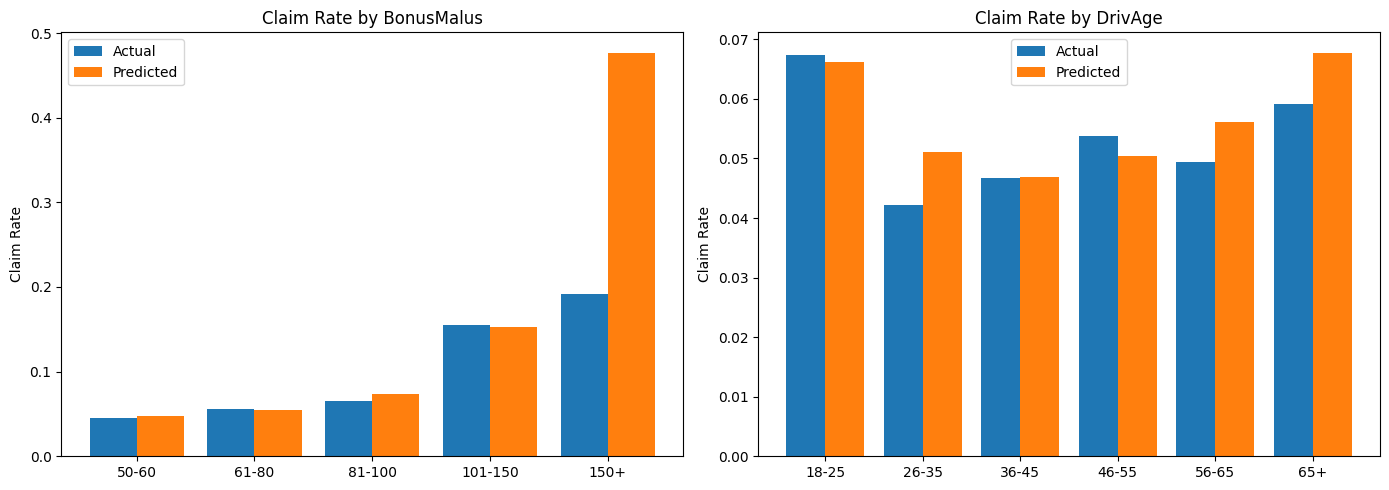

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                       

# Get predictions on full training + test set for this analysis                                                       
X_all_sm = sm.add_constant(pd.concat([X_freq_train, X_freq_test]))
exp_all = pd.concat([exp_train, exp_test])
df_freq['predicted_rate'] = result_freq.predict(X_all_sm, offset=np.log(exp_all))
df_freq['HasClaim'] = (df_freq['ClaimNb'] != 0).astype(int)
df_freq['actual_rate'] = df_freq['HasClaim']

# BonusMalus
bm_bins = pd.cut(df_freq['BonusMalus'], bins=[49,60,80,100,150,230],
labels=['50-60','61-80','81-100','101-150','150+'])
actual_bm = df_freq.groupby(bm_bins)['actual_rate'].mean()
pred_bm = df_freq.groupby(bm_bins)['predicted_rate'].mean()

x = range(len(actual_bm))
axes[0].bar(x, actual_bm, width=0.4, label='Actual', align='center')                                                  
axes[0].bar([i + 0.4 for i in x], pred_bm, width=0.4, label='Predicted', align='center')                              
axes[0].set_xticks([i + 0.2 for i in x])                                                                              
axes[0].set_xticklabels(actual_bm.index)                                                                              
axes[0].set_title('Claim Rate by BonusMalus')                                                                         
axes[0].set_ylabel('Claim Rate')                          
axes[0].legend()                                                                                                      
                                                                                                                    
# DrivAge
age_bins = pd.cut(df_freq['DrivAge'], bins=[17,25,35,45,55,65,100],                                                   
labels=['18-25','26-35','36-45','46-55','56-65','65+'])                                                               
actual_age = df_freq.groupby(age_bins)['actual_rate'].mean()
pred_age = df_freq.groupby(age_bins)['predicted_rate'].mean()                                                         
                                                        
x = range(len(actual_age))                                                                                            
axes[1].bar(x, actual_age, width=0.4, label='Actual', align='center')
axes[1].bar([i + 0.4 for i in x], pred_age, width=0.4, label='Predicted', align='center')                             
axes[1].set_xticks([i + 0.2 for i in x])
axes[1].set_xticklabels(actual_age.index)                                                                             
axes[1].set_title('Claim Rate by DrivAge')                                                                            
axes[1].set_ylabel('Claim Rate')
axes[1].legend()                                                                                                      
                                                        
plt.tight_layout()
plt.savefig('../results/04_freq_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**BonusMalus (left)**

The model correctly captures the upward trend. Predicted rates rise monotonically as BonusMalus increases, which reflects the coefficient being positive and significant in the GLM summary.

However the model consistently underpredicts across all bins, and the magnitude of underprediction varies considerably. For the three lowest risk bins (50-60, 61-80, 81-100) predictions sit around 0.025-0.030 while actual rates range from 0.046 to 0.065. This is a systematic underestimate of roughly 50-60% in these groups. The model performs best at the highest risk band (150+) where predicted 0.158 is close to actual 0.191, a gap of around 17%.

This compression toward the mean is a known limitation of GLMs with few features. The model cannot fully separate the cleanest drivers from average-risk drivers because BonusMalus alone, as a linear term, does not carry enough discriminating power at the lower end of the range. In practice actuaries often apply credibility adjustments or add interaction terms to address this.

**DrivAge (right)**

Young drivers (18-25) are clearly the highest risk group at 0.068. Rates drop sharply into the mid-twenties, remain relatively stable through middle age at around 0.043-0.055, then rise modestly for the 65+ group to 0.059.

The GLM substantially underpredicts all age groups, with predictions ranging only from 0.023 to 0.046. More importantly it fails to capture the non-linear shape of the relationship. The model predicts a gentle upward slope across age groups rather than the sharp peak at 18-25 and the moderate elevation at 65+. Middle-aged drivers (26-45) are the least risky in reality but the model assigns them almost the same predicted rate as older drivers.

This is a direct consequence of the GLM treating DrivAge as a linear predictor. The actual relationship requires at minimum a quadratic term or binned age categories to fit properly. This is precisely the limitation XGBoost will address since tree-based models find non-linear splits automatically. We would expect XGBoost to much better separate the 18-25 group from the rest and to correctly identify the modest uptick at 65+.

**Overall**

Both charts point to the same underlying issue. The Poisson GLM captures the direction of relationships correctly but compresses predictions toward the mean and misses non-linearities. This is expected for a baseline model. The Poisson deviance of 46,581 and the calibration gaps here set the benchmark that XGBoost and the neural network will be judged against.

***
## 6. Save Models, Predictions and Metrics

Notebook 5 is a pure comparison notebook — it must not refit anything. Everything it
needs is written here: the fitted models, the test-set predictions, and the metrics.

This cell also writes `results/test_split.npz`, the **shared definition of the test set**.
Notebooks 3 and 4 reproduce the same split from the same seed, but notebook 5 should never
have to touch the raw CSVs or re-derive a split just to know which rows it is looking at.

One detail matters for notebook 5's pure premium calculation. Pure premium is
frequency × severity *for the same policy*, so we need the severity model's prediction on
the **frequency** test rows, not just the severity test rows. That is `sev_on_freq_test`
below. Computing it here — from `X_freq_test` directly — guarantees it stays aligned with
`freq_test_rate`. (Deriving it downstream by positional slicing silently misaligns the two,
because `train_test_split` shuffles.)

In [18]:
import json, pickle

# The severity and frequency design matrices share identical columns in identical
# order, so the severity model can be scored directly on the frequency test rows.
assert list(X_test.columns) == list(X_freq_test.columns), 'design matrices misaligned'

# Severity GLM applied to the frequency test policies — the severity half of pure premium
sev_on_freq_test = result.predict(sm.add_constant(X_freq_test))

# ── Models ───────────────────────────────────────────────────────────────────
# Pickled as plain coefficient arrays (order: const, then X_train.columns) rather
# than via GLMResultsWrapper.save(), which embeds the full training design matrix
# (~400MB) that the dashboard never needs.
with open('../models/glm_sev.pkl', 'wb') as f:
    pickle.dump(np.asarray(result.params), f)
with open('../models/glm_freq.pkl', 'wb') as f:
    pickle.dump(np.asarray(result_freq.params), f)

# Feature order, so a future notebook can build a design matrix that matches
with open('../models/preprocessing.pkl', 'wb') as f:
    pickle.dump({'features': features, 'cat_cols': ['Area', 'VehBrand', 'VehGas', 'Region'],
                 'columns': list(X_train.columns)}, f)

# ── Shared test-set definition (written once, here) ──────────────────────────
np.savez_compressed(
    '../results/test_split.npz',
    freq_idx_test        = X_freq_test.index.values.astype(np.int64),
    freq_y_test          = y_freq_test.values.astype(np.float32),
    freq_exposure_test   = np.asarray(exp_test, dtype=np.float32),
    freq_bonusmalus_test = df_freq.loc[X_freq_test.index, 'BonusMalus'].values.astype(np.float32),
    freq_drivage_test    = df_freq.loc[X_freq_test.index, 'DrivAge'].values.astype(np.float32),
    sev_idx_test         = X_test.index.values.astype(np.int64),
    sev_y_test           = y_test.values.astype(np.float32),
)

# ── Predictions ──────────────────────────────────────────────────────────────
np.savez_compressed(
    '../results/predictions_glm.npz',
    sev_test_pred    = np.asarray(y_pred, dtype=np.float32),
    freq_test_rate   = np.asarray(y_freq_pred / exp_test, dtype=np.float32),
    sev_on_freq_test = np.asarray(sev_on_freq_test, dtype=np.float32),
)

# ── Metrics ──────────────────────────────────────────────────────────────────
with open('../results/metrics_glm.json', 'w') as f:
    json.dump({
        'model': 'GLM',
        'severity':  {'MAE': float(mae),      'RMSE': float(rmse),      'GammaDeviance':   float(gd)},
        'frequency': {'MAE': float(mae_freq), 'RMSE': float(rmse_freq), 'PoissonDeviance': float(pd_score)},
    }, f, indent=2)

print('Saved GLM models, predictions and metrics.')
print(f'  test_split.npz       — {len(X_freq_test):,} frequency rows, {len(X_test):,} severity rows')
print(f'  predictions_glm.npz  — sev {y_pred.shape}, freq {y_freq_pred.shape}, sev_on_freq {sev_on_freq_test.shape}')
print(f'  metrics_glm.json     — sev MAE {mae:,.2f} | freq Poisson Deviance {pd_score:,.2f}')

Saved GLM models, predictions and metrics.
  test_split.npz       — 135,603 frequency rows, 5,288 severity rows
  predictions_glm.npz  — sev (5288,), freq (135603,), sev_on_freq (135603,)
  metrics_glm.json     — sev MAE 1,102.26 | freq Poisson Deviance 43,585.73
